#  Proposal

The current notebook proposal is help to review the Dataset generate by the function DDM Generator to compare Robust Scenarios to get a treatment plan for Cancer.

In [1]:
from daoPlotter.classes.Coliimator import Collimator

dataInstance = 86

def load_index_instance():
    folderIndexInstanceFile = "data/index_instances.txt"
    index_instance = {}
    with open(folderIndexInstanceFile, 'r') as file:
        folderScenario = file.readlines()
        index_instance = folderScenario[dataInstance-1]

    instance_dir_file_path = f"data/{index_instance}/Instance.txt"

    #p Opening Instance.txt from the selected instance and taking only the scenario part
    print("Loading scenarios from the selected instance...")
    scenario_list = []
    anglesList = []
    with open(instance_dir_file_path, 'r') as file:
        folderScenario = file.readlines()
        for i in range(len(folderScenario)):
            line = folderScenario[i].strip()
            if i == 0:
                anglesList = line.split(' ')
                continue
            else:
                parts = line.split('/')
                scenario = parts[2]  # Assuming the scenario is always the third part
                if scenario not in scenario_list:
                    scenario_list.append(scenario)

    collimatorList = []
    for scenario in scenario_list:
        coordinates_file_path = f"data/{index_instance}/{scenario}/coordinates_instance.txt"

        coordinates_beam_file_path = {}
        with open(coordinates_file_path, 'r') as file:
            lines = file.readlines()
            for line in lines:
                parts = line.strip().split(';')
                index_angle = parts[0]
                local_position = parts[1]
                coordinates_beam_file_path[index_angle] = local_position

        collimator = Collimator(anglesList,coordinates_beam_file_path,scenario)
        collimatorList.append(collimator)

    return collimatorList

collimatorList = load_index_instance()
print("Collimator loaded successfully.")

Loading scenarios from the selected instance...
Collimator loaded successfully.


In [4]:
for collimator in collimatorList:
    print(collimator.scenario_tag)


Scenario_1
Scenario_2
Scenario_3
Scenario_4
Scenario_5


<Figure size 432x288 with 0 Axes>

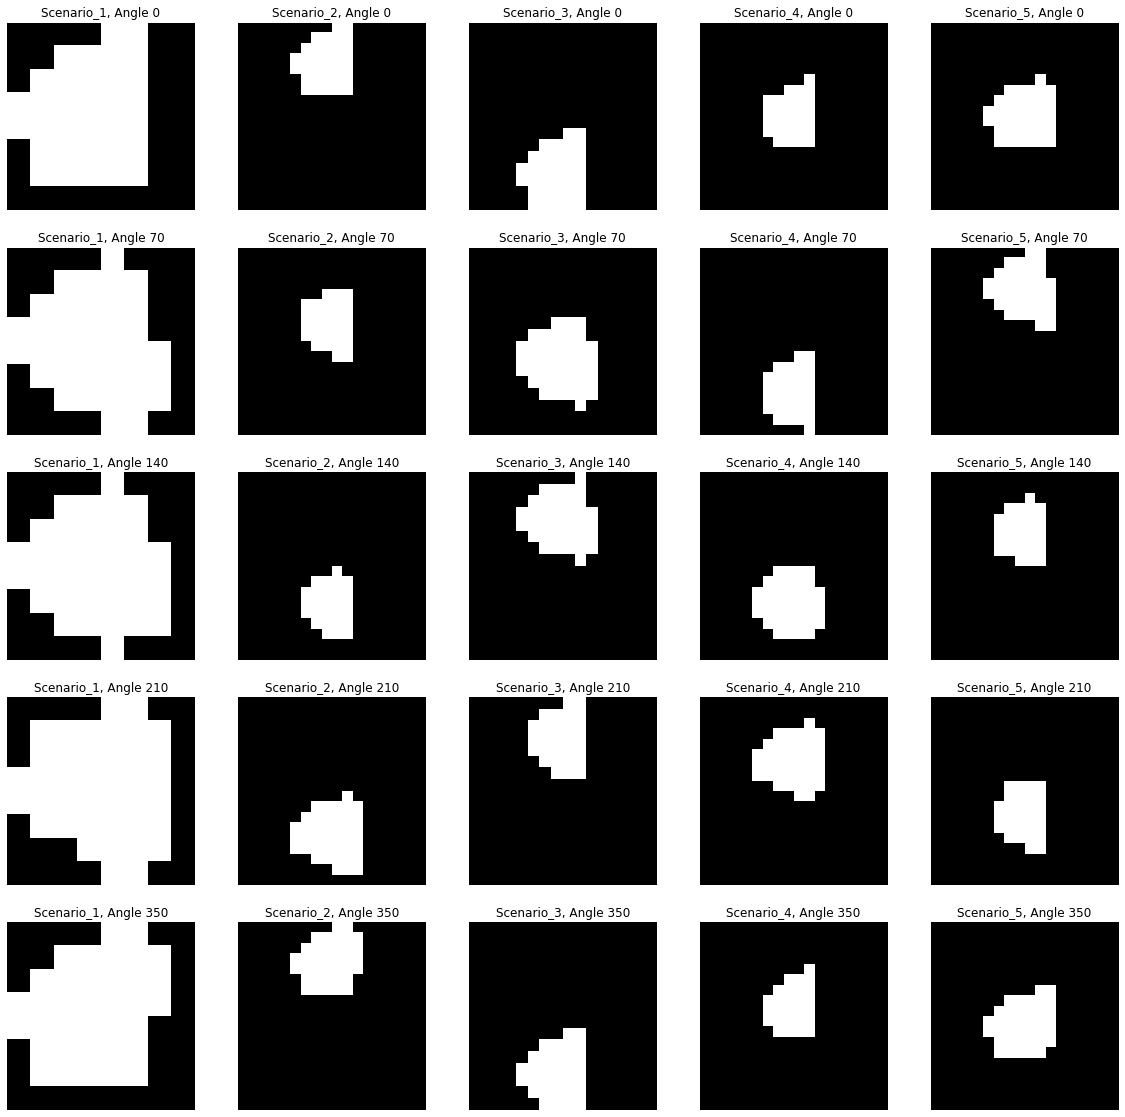

<Figure size 432x288 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo (matriz de intensidad 10x10)
data = np.random.rand(10, 10) 

#Crear una figura que contenga muchos subplots
fig, axs = plt.subplots(len(collimatorList), len(collimator.angles), figsize=(20, 20))
for j, collimator in enumerate(collimatorList):
    for i, angle in enumerate(collimator.angles):
        collimator_position = collimator.activate_range[angle]
        dimension = collimator.x
        data = []
        for c in range(len(collimator_position)):
            leaf = collimator_position[c]
            row = []
            if leaf == [-1,-1]:
                row = [0 for _ in range(dimension)]
            else:
                row = []
                for r in range(dimension):
                    if r < leaf[0] or r > leaf[1]:
                        row.append(0)
                    else:
                        row.append(1)
            data.append(row)
        axs[i, j].imshow(data, cmap='gray')
        axs[i, j].set_title(f'{collimator.scenario_tag}, Angle {angle}')
        axs[i, j].axis('off')


plt.figure()
# Uso de 'gray' para un mapa de calor en tonos de gris/blanco y negro